## Exercise 0 - pandas repetition
    -a Do some EDA with info, find out column names, shape of dataset, describe method to get summary descriptive statistics.
    -b Draw a line chart of quantity for each year. Is there a year that should be skipped?
    -c Draw a line chart of average CO2 emissions for same years that as in b)
    -d Draw a line chart of all years and months for import
    -e Draw a line chart of all years and months for average CO2 emissions
    -f Draw a line chart of all years and months for electric cars import where it's relevant.
    -g Draw a line chart of average diesel share per year
    -h Discuss some findings with a friend based on this dataset, and do plot more graphs

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../../data/norway_new_car_sales_by_month.csv", index_col=0, parse_dates=True).reset_index()

df.head()

,Year,Month,Quantity,Quantity_YoY,Import,Import_YoY,Used,Used_YoY,Avg_CO2,Bensin_Co2,Diesel_Co2,Quantity_Diesel,Diesel_Share,Diesel_Share_LY,Quantity_Hybrid,Quantity_Electric,Import_Electric
0,2007-01-01,1,12685,5227,2276,257,NaN,NaN,152,155,152,10072,79.4,52.5,NaN,NaN,NaN
1,2007-01-01,2,9793,2448,1992,-89,NaN,NaN,156,159,155,7222,73.7,47.4,NaN,NaN,NaN
2,2007-01-01,3,11264,1445,2626,45,NaN,NaN,159,161,158,7965,70.7,48.1,NaN,NaN,NaN
3,2007-01-01,4,8854,504,2220,-130,NaN,NaN,160,165,158,6116,69.1,48.4,NaN,NaN,NaN
4,2007-01-01,5,12007,1592,2881,7,NaN,NaN,160,163,159,8519,71.0,49.1,NaN,NaN,NaN


Task B)

In [3]:
df.groupby("Year")["Month"].nunique()


Year
2007-01-01    12
2008-01-01    12
2009-01-01    12
2010-01-01    12
2011-01-01    12
2012-01-01    12
2013-01-01    12
2014-01-01    12
2015-01-01    12
2016-01-01    12
2017-01-01     1
Name: Month, dtype: int64

In [4]:
df_valid_years = df.query("Year !=2017")

df_valid_years.groupby("Year")["Quantity"].sum()

Year
2007-01-01    129195
2008-01-01    110617
2009-01-01     98675
2010-01-01    127754
2011-01-01    138345
2012-01-01    137967
2013-01-01    142151
2014-01-01    144202
2015-01-01    150686
2016-01-01    154603
Name: Quantity, dtype: int64

<Axes: title={'center': 'Total quantity of cars sold per year'}, xlabel='Year', ylabel='Quantity'>

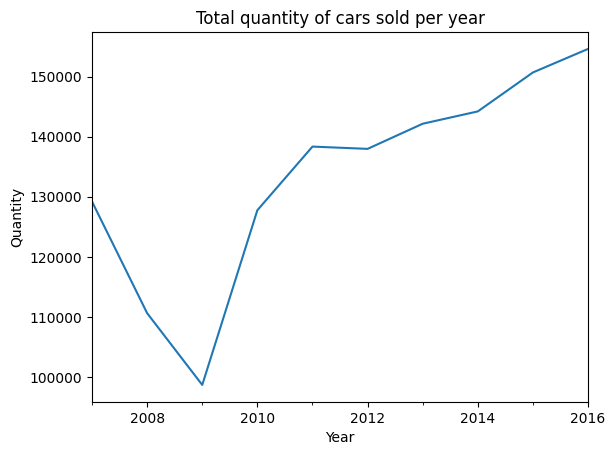

In [5]:
df_valid_years.groupby("Year")["Quantity"].sum().plot(
    kind="line",
    title="Total quantity of cars sold per year",
    xlabel="Year",
    ylabel="Quantity",
)

Task C)

In [6]:
df_valid_years.groupby("Year")["Avg_CO2"].mean()

Year
2007-01-01    159.000000
2008-01-01    158.000000
2009-01-01    150.916667
2010-01-01    140.666667
2011-01-01    134.000000
2012-01-01    129.916667
2013-01-01    123.000000
2014-01-01    110.416667
2015-01-01     99.750000
2016-01-01     93.333333
Name: Avg_CO2, dtype: float64

<Axes: title={'center': 'Total average CO2 emissions per year'}, xlabel='Year', ylabel='Avg CO2'>

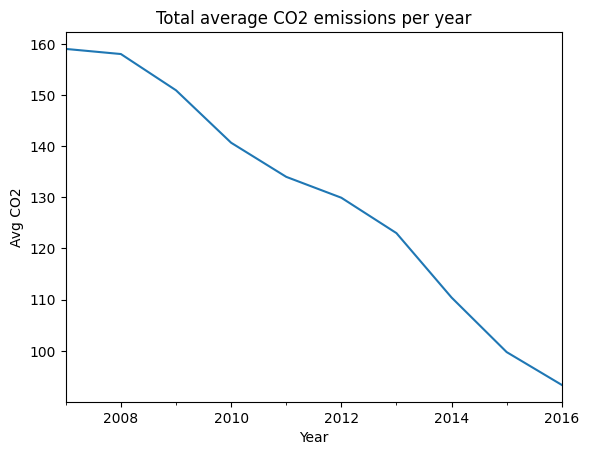

In [7]:
df_valid_years.groupby("Year")["Avg_CO2"].mean().plot(
    kind="line",
    title="Total average CO2 emissions per year",
    xlabel="Year",
    ylabel="Avg CO2",
)

Task D)

In [8]:
import_year_months_df = df.groupby(["Year", "Month"])["Import"].sum().unstack(level=0)

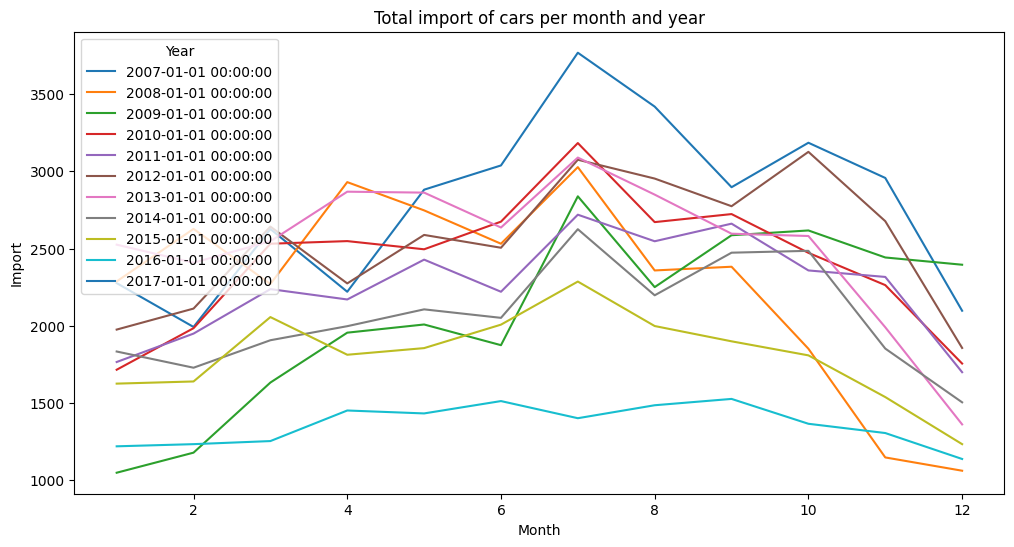

In [9]:
import matplotlib.pyplot as plt

ax = import_year_months_df.plot(
    figsize=(12,6),
    title="Total import of cars per month and year"
)

ax.set_xlabel("Month")
ax.set_ylabel("Import")
ax.legend(title="Year")

plt.show()


Task E)

In [10]:
df.columns

Index(['Year', 'Month', 'Quantity', 'Quantity_YoY', 'Import', 'Import_YoY',
       'Used', 'Used_YoY', 'Avg_CO2', 'Bensin_Co2', 'Diesel_Co2',
       'Quantity_Diesel', 'Diesel_Share', 'Diesel_Share_LY', 'Quantity_Hybrid',
       'Quantity_Electric', 'Import_Electric'],
      dtype='object')

In [11]:
import duckdb as db

query = db.query(
    """
SELECT
    Year,
    Month,
    AVG(Avg_CO2) AS Total_Avg_CO2,
    FROM df
    GROUP BY Year, Month
    ORDER BY Year, Month
"""
).df()

query.head()

,Year,Month,Total_Avg_CO2
0,2007-01-01,1,152.0
1,2007-01-01,2,156.0
2,2007-01-01,3,159.0
3,2007-01-01,4,160.0
4,2007-01-01,5,160.0


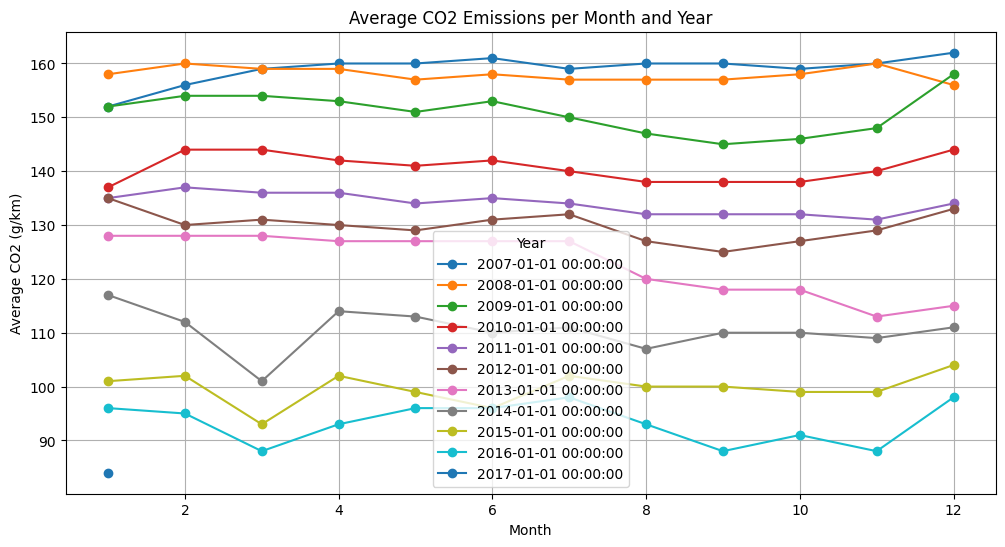

In [12]:
import matplotlib.pyplot as plt

avg_co2_pivot = query.pivot(index="Month", columns="Year", values="Total_Avg_CO2")

ax = avg_co2_pivot.plot(figsize=(12,6), marker="o")
ax.set_title("Average CO2 Emissions per Month and Year")
ax.set_xlabel("Month")
ax.set_ylabel("Average CO2 (g/km)")
ax.legend(title="Year")
plt.grid(True)
plt.show()

task f

In [13]:
df.head()

,Year,Month,Quantity,Quantity_YoY,Import,Import_YoY,Used,Used_YoY,Avg_CO2,Bensin_Co2,Diesel_Co2,Quantity_Diesel,Diesel_Share,Diesel_Share_LY,Quantity_Hybrid,Quantity_Electric,Import_Electric
0,2007-01-01,1,12685,5227,2276,257,NaN,NaN,152,155,152,10072,79.4,52.5,NaN,NaN,NaN
1,2007-01-01,2,9793,2448,1992,-89,NaN,NaN,156,159,155,7222,73.7,47.4,NaN,NaN,NaN
2,2007-01-01,3,11264,1445,2626,45,NaN,NaN,159,161,158,7965,70.7,48.1,NaN,NaN,NaN
3,2007-01-01,4,8854,504,2220,-130,NaN,NaN,160,165,158,6116,69.1,48.4,NaN,NaN,NaN
4,2007-01-01,5,12007,1592,2881,7,NaN,NaN,160,163,159,8519,71.0,49.1,NaN,NaN,NaN


In [17]:
import duckdb as db

electric_cars_df = db.query(
    """
    SELECT 
        Year,
        Month,
        SUM(Import_Electric) AS Total_Import_Electric
        FROM df
        WHERE Import_Electric > 0
        GROUP BY Year, Month
        ORDER BY Year, Month
    """

).df()

electric_cars_df.tail()

,Year,Month,Total_Import_Electric
48,2016-01-01,9,517.0
49,2016-01-01,10,486.0
50,2016-01-01,11,502.0
51,2016-01-01,12,361.0
52,2017-01-01,1,494.0


In [ ]:
electric_pivot = electric_cars_df.pivot(index="Month", columns="Year", values="Total_Import_Electric")


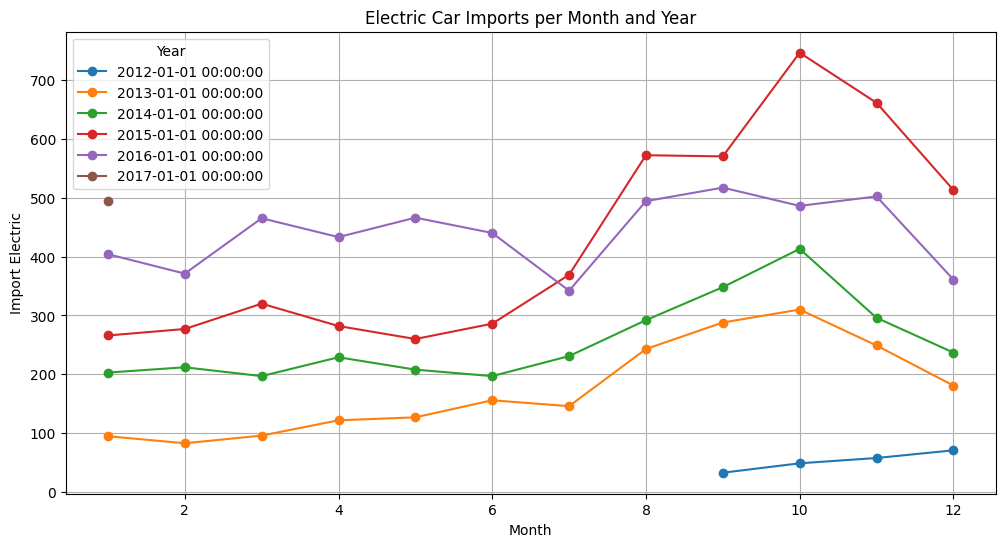

In [ ]:
import matplotlib.pyplot as plt

ax = electric_pivot.plot(figsize=(12,6), marker="o")
ax.set_title("Electric Car Imports per Month and Year")
ax.set_xlabel("Month")
ax.set_ylabel("Import Electric")
ax.legend(title="Year")
plt.grid(True)
plt.show()

task g

In [ ]:
df.head()

,Year,Month,Quantity,Quantity_YoY,Import,Import_YoY,Used,Used_YoY,Avg_CO2,Bensin_Co2,Diesel_Co2,Quantity_Diesel,Diesel_Share,Diesel_Share_LY,Quantity_Hybrid,Quantity_Electric,Import_Electric
0,2007-01-01,1,12685,5227,2276,257,NaN,NaN,152,155,152,10072,79.4,52.5,NaN,NaN,NaN
1,2007-01-01,2,9793,2448,1992,-89,NaN,NaN,156,159,155,7222,73.7,47.4,NaN,NaN,NaN
2,2007-01-01,3,11264,1445,2626,45,NaN,NaN,159,161,158,7965,70.7,48.1,NaN,NaN,NaN
3,2007-01-01,4,8854,504,2220,-130,NaN,NaN,160,165,158,6116,69.1,48.4,NaN,NaN,NaN
4,2007-01-01,5,12007,1592,2881,7,NaN,NaN,160,163,159,8519,71.0,49.1,NaN,NaN,NaN


In [ ]:
diesel_share_year = df.groupby("Year")["Diesel_Share"].mean()

diesel_share_year.head(11)

Year
2007-01-01    74.216667
2008-01-01    72.300000
2009-01-01    72.241667
2010-01-01    74.875000
2011-01-01    75.550000
2012-01-01    64.391667
2013-01-01    52.933333
2014-01-01    48.783333
2015-01-01    40.991667
2016-01-01    31.691667
2017-01-01    26.300000
Name: Diesel_Share, dtype: float64

<Axes: title={'center': 'Average Diesel Share per Year'}, xlabel='Year', ylabel='Diesel Share (%)'>

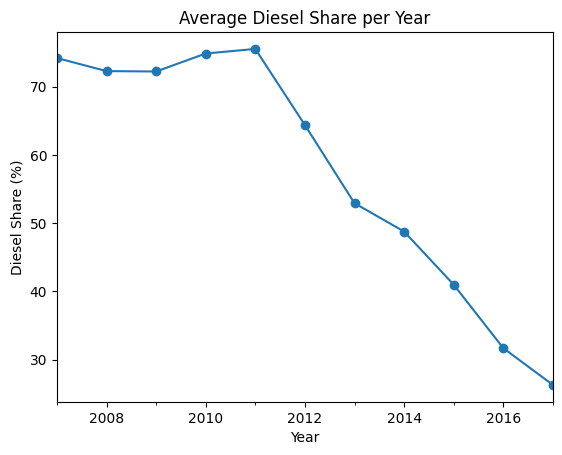

In [ ]:
diesel_share_year.plot(
    kind="line",
    title="Average Diesel Share per Year",
    xlabel="Year",
    ylabel="Diesel Share (%)",
    marker="o"
)